# Symulacja i Analiza Statystyczna Szpitalnego Oddziału Ratunkowego (SOR)

Ten notatnik przeprowadza symulację działania Szpitalnego Oddziału Ratunkowego (SOR) przy użyciu modelu kolejkowego M/M/c. Celem jest zrozumienie dynamiki systemu, oszacowanie kluczowych metryk wydajności (jak czas oczekiwania) oraz porównanie wyników z modelem teoretycznym za pomocą testów statystycznych.

### 1. Import niezbędnych bibliotek

Na początek importujemy wszystkie biblioteki, które będą potrzebne do symulacji, obliczeń i analizy statystycznej.

In [1456]:
import heapq
import random
import numpy as np
import math
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Definicja klasy symulatora

Poniższa komórka zawiera pełną klasę SORSimulator_MMc, która jest sercem naszej symulacji. Implementuje ona logikę symulacji dla systemu M/M/c, gdzie pacjenci są obsługiwani w kolejności przybycia (FIFO).

In [1457]:
class SORSimulator_MMc:
    """
    Symulator Szpitalnego Oddziału Ratunkowego (SOR) jako klasyczna kolejka M/M/c.
    Pacjenci są obsługiwani w kolejności przybycia (FIFO).
    Implementuje dyskretną symulację zdarzeniową.
    """
    def __init__(self, lambda_rate, mu_rate, c, max_patients):
        if not (lambda_rate > 0 and mu_rate > 0 and c > 0 and max_patients > 0):
            raise ValueError("Parametry lambda, mu, c oraz max_patients muszą być dodatnie.")
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.c = c
        self.max_patients = max_patients

        self.rho = self.lambda_rate / (self.c * self.mu_rate)
        if self.rho >= 1:
            print(f"UWAGA: System jest niestabilny (rho = {self.rho:.3f} >= 1).")

        # Inicjalizacja stanu
        self.clock = 0.0
        self.event_queue = []
        self.doctor_free_times = [0.0] * self.c
        self.waiting_queue = []
        
        self.patient_data = {}
        self.num_patients_treated = 0
        self.next_patient_id = 0
        
        self.generated_interarrival_times = []
        self.generated_treatment_times = []

    def _generate_exponential_time(self, rate):
        return random.expovariate(rate)

    def _schedule_event(self, time, event_type, data):
        heapq.heappush(self.event_queue, (time, event_type, data))

    def run(self):
        """Główna pętla symulacji."""
        print("\n" + "="*50)
        print("      URUCHAMIANIE SYMULACJI SOR (model M/M/c FIFO)")
        print("="*50)
        initial_arrival_time = self._generate_exponential_time(self.lambda_rate)
        self.generated_interarrival_times.append(initial_arrival_time)
        self._schedule_event(initial_arrival_time, "ARRIVAL", {'patient_id': self.next_patient_id})
        self.next_patient_id += 1

        while self.num_patients_treated < self.max_patients:
            if not self.event_queue:
                print("Błąd: Kolejka zdarzeń pusta przed obsłużeniem wszystkich pacjentów.")
                break
            
            event_time, event_type, data = heapq.heappop(self.event_queue)
            self.clock = event_time
            
            if event_type == "ARRIVAL":
                self._handle_arrival(data['patient_id'])
            elif event_type == "DEPARTURE":
                self._handle_departure(data['patient_id'], data['doctor_id'])
        
        print(f"      --- Zakończono symulację. Obsłużono {self.num_patients_treated} pacjentów. ---")

    def _handle_arrival(self, patient_id):
        self.patient_data[patient_id] = {'arrival_time': self.clock}

        if self.next_patient_id < self.max_patients:
            interarrival_time = self._generate_exponential_time(self.lambda_rate)
            self._schedule_event(self.clock + interarrival_time, "ARRIVAL", {'patient_id': self.next_patient_id})
            self.next_patient_id += 1
            self.generated_interarrival_times.append(interarrival_time)
        
        # Znajdź lekarza, który będzie wolny najwcześniej
        earliest_free_time = min(self.doctor_free_times)
        if earliest_free_time <= self.clock:
            doctor_id = self.doctor_free_times.index(earliest_free_time)
            self._start_treatment(patient_id, doctor_id)
        else:
            self.waiting_queue.append(patient_id)

    def _handle_departure(self, patient_id, doctor_id):
        self.patient_data[patient_id]['departure_time'] = self.clock
        self.num_patients_treated += 1
        
        if self.waiting_queue:
            next_patient_id = self.waiting_queue.pop(0)
            self._start_treatment(next_patient_id, doctor_id)

    def _start_treatment(self, patient_id, doctor_id):
        self.patient_data[patient_id]['treatment_start_time'] = self.clock

        treatment_time = self._generate_exponential_time(self.mu_rate)
        self.generated_treatment_times.append(treatment_time)
        departure_time = self.clock + treatment_time
        self.doctor_free_times[doctor_id] = departure_time
        self._schedule_event(departure_time, "DEPARTURE", {'patient_id': patient_id, 'doctor_id': doctor_id})

    def calculate_performance_metrics(self):
        wait_times = []
        system_times = []
        
        for data in self.patient_data.values():
            if 'departure_time' in data and 'treatment_start_time' in data:
                wait_times.append(data['treatment_start_time'] - data['arrival_time'])
                system_times.append(data['departure_time'] - data['arrival_time'])
        
        if not wait_times:
            return None
        return {
            "mean_wait_time": np.mean(wait_times),
            "mean_system_time": np.mean(system_times),
            "all_wait_times": wait_times
        }

### 3. Funkcje pomocnicze do analizy

Tutaj definiujemy funkcje, które obliczą wartości teoretyczne dla modelu M/M/c oraz przeprowadzą wnioskowanie statystyczne.

In [1458]:
def calculate_theoretical_values(lambda_rate, mu_rate, c):
    """Oblicza teoretyczne wartości dla kolejki M/M/c."""
    rho = lambda_rate / (c * mu_rate)
    if rho >= 1:
        return {"Wq": float('inf'), "Lq": float('inf'), "P0": 0, "rho": rho}
    sum_part = sum([(c * rho)**n / math.factorial(n) for n in range(c)])
    last_part = (c * rho)**c / (math.factorial(c) * (1 - rho))
    P0 = 1 / (sum_part + last_part)
    Lq = (P0 * (lambda_rate / mu_rate)**c * rho) / (math.factorial(c) * (1 - rho)**2)
    Wq = Lq / lambda_rate
    W = Wq + (1 / mu_rate)

    print("\n" + "="*50)
    print("      TEORETYCZNE WARTOŚCI dla M/M/c")
    print("="*50)
    print(f"      Rho (obciążenie systemu): {rho:.4f}")
    print(f"      Wq (średni czas oczekiwania w kolejce): {Wq:.4f} godzin ({Wq * 60:.2f} minut)")
    print(f"      Lq (średnia liczba pacjentów w kolejce): {Lq:.4f}")
    print(f"      W (średni czas w systemie): {W:.4f} godzin ({W * 60:.2f} minut)")
    print(f"      P0 (prawdopodobieństwo, że system jest pusty): {P0:.4f}")

    return {"Wq": Wq, "Lq": Lq, "W": W, "P0": P0, "rho": rho}

def statistical_inference(simulator, sim_results, theoretical_values):
    """Przeprowadza i prezentuje wyniki wnioskowania statystycznego."""
    print("\n" + "="*50)
    print("      WNIOSKOWANIE STATYSTYCZNE")
    print("="*50)

    print("\n1. Testy Kołmogorowa-Smirnowa dla założeń wejściowych")
    ks_arrival = stats.kstest(simulator.generated_interarrival_times, 'expon', args=(0, 1/simulator.lambda_rate))
    print(f"\n   a) Test K-S dla czasów między przybyciami (lambda={simulator.lambda_rate}):")
    print(f"      Statystyka D = {ks_arrival.statistic:.4f}, p-wartość = {ks_arrival.pvalue:.4f}")
    if ks_arrival.pvalue > 0.05:
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0.")
    else:
        print("      Wniosek: ODRZUCONO H0.")

    ks_service = stats.kstest(simulator.generated_treatment_times, 'expon', args=(0, 1/simulator.mu_rate))
    print(f"\n   b) Test K-S dla czasów leczenia (mu={simulator.mu_rate}):")
    print(f"      Statystyka D = {ks_service.statistic:.4f}, p-wartość = {ks_service.pvalue:.4f}")
    if ks_service.pvalue > 0.05:
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0.")
    else:
        print("      Wniosek: ODRZUCONO H0.")

    print("\n2. Porównanie wyników symulacji z modelem teoretycznym")
    mean_wait_sim = sim_results['mean_wait_time']
    theoretical_wq = theoretical_values['Wq']
    
    print("\n   a) Test t-Studenta dla średniego czasu oczekiwania (Wq)")
    print(f"      H0: Średnia z symulacji ({mean_wait_sim:.4f}) jest równa wartości teoretycznej ({theoretical_wq:.4f}).")
    ttest_result = stats.ttest_1samp(a=sim_results['all_wait_times'], popmean=theoretical_wq)
    print(f"      Statystyka t = {ttest_result.statistic:.4f}, p-wartość = {ttest_result.pvalue:.4f}")
    if ttest_result.pvalue > 0.05: 
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0. Wyniki zgodne z teorią.")
    else:
        print("      Wniosek: ODRZUCONO H0. Średnie różnią się statystycznie istotnie.")
        
    print("\n   b) 95% Przedział ufności dla średniego czasu oczekiwania (Wq)")
    confidence_interval = stats.t.interval(0.95, len(sim_results['all_wait_times'])-1, loc=mean_wait_sim, scale=stats.sem(sim_results['all_wait_times']))
    print(f"      Obliczony przedział: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")
    print(f"      Wartość teoretyczna: {theoretical_wq:.4f}")
    if confidence_interval[0] <= theoretical_wq <= confidence_interval[1]:
        print("      Wniosek: OK. Wartość teoretyczna mieści się w przedziale ufności.")
    else:
        print("      Wniosek: Wartość teoretyczna POZA przedziałem ufności.")

### 4. Uruchomienie symulacji i analiza wyników

W tej części definiujemy parametry wejściowe, uruchamiamy symulator i wywołujemy funkcje analityczne.

In [1459]:
# --- Parametry wejściowe ---
LAMBDA_RATE = 5.0    # Średnio 5 pacjentów przybywa na godzinę
MU_RATE = 2.0        # Jeden lekarz obsługuje średnio 2 pacjentów na godzinę
C_DOCTORS = 3        # 3 lekarzy na dyżurze
MAX_PATIENTS = 5000  # Liczba pacjentów do zasymulowania

In [1460]:
theoretical_vals = calculate_theoretical_values(LAMBDA_RATE, MU_RATE, C_DOCTORS)


      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.8333
      Wq (średni czas oczekiwania w kolejce): 0.7022 godzin (42.13 minut)
      Lq (średnia liczba pacjentów w kolejce): 3.5112
      W (średni czas w systemie): 1.2022 godzin (72.13 minut)
      P0 (prawdopodobieństwo, że system jest pusty): 0.0449


In [1461]:
sor_simulator = SORSimulator_MMc(LAMBDA_RATE, MU_RATE, C_DOCTORS, MAX_PATIENTS)
sor_simulator.run()
sim_results = sor_simulator.calculate_performance_metrics()

if sim_results:
    print("\n      --- Wyniki z symulacji (model M/M/c FIFO) ---")
    wq_sim_h = sim_results['mean_wait_time']
    w_sim_h = sim_results['mean_system_time']
    print(f"            Średni czas oczekiwania na lekarza (Wq): {wq_sim_h:.4f} godzin ({wq_sim_h*60:.2f} minut)")
    print(f"            Średni czas pobytu na SOR (W):          {w_sim_h:.4f} godzin ({w_sim_h*60:.2f} minut)")
    



      URUCHAMIANIE SYMULACJI SOR (model M/M/c FIFO)
      --- Zakończono symulację. Obsłużono 5000 pacjentów. ---

      --- Wyniki z symulacji (model M/M/c FIFO) ---
            Średni czas oczekiwania na lekarza (Wq): 0.6720 godzin (40.32 minut)
            Średni czas pobytu na SOR (W):          1.1704 godzin (70.23 minut)


In [1462]:
# --- Wnioskowanie statystyczne ---
statistical_inference(sor_simulator, sim_results, theoretical_vals)


      WNIOSKOWANIE STATYSTYCZNE

1. Testy Kołmogorowa-Smirnowa dla założeń wejściowych

   a) Test K-S dla czasów między przybyciami (lambda=5.0):
      Statystyka D = 0.0085, p-wartość = 0.8597
      Wniosek: OK. Brak podstaw do odrzucenia H0.

   b) Test K-S dla czasów leczenia (mu=2.0):
      Statystyka D = 0.0060, p-wartość = 0.9940
      Wniosek: OK. Brak podstaw do odrzucenia H0.

2. Porównanie wyników symulacji z modelem teoretycznym

   a) Test t-Studenta dla średniego czasu oczekiwania (Wq)
      H0: Średnia z symulacji (0.6720) jest równa wartości teoretycznej (0.7022).
      Statystyka t = -2.4780, p-wartość = 0.0132
      Wniosek: ODRZUCONO H0. Średnie różnią się statystycznie istotnie.

   b) 95% Przedział ufności dla średniego czasu oczekiwania (Wq)
      Obliczony przedział: (0.6480, 0.6959)
      Wartość teoretyczna: 0.7022
      Wniosek: Wartość teoretyczna POZA przedziałem ufności.


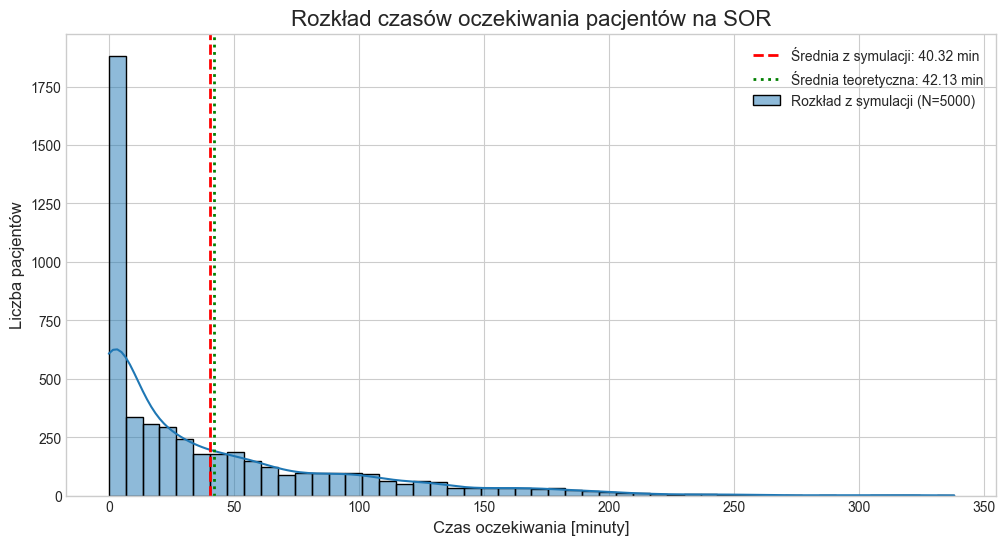

In [1463]:
# Sprawdzenie, czy symulacja została uruchomiona i mamy wyniki
if 'sim_results' in locals() and sim_results:
    wait_times_minutes = [t * 60 for t in sim_results['all_wait_times']]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))

    # Histogram
    sns.histplot(wait_times_minutes, bins=50, kde=True, ax=ax,
                 label=f"Rozkład z symulacji (N={len(wait_times_minutes)})")
    
    # Linie dla wartości średnich
    mean_sim_min = sim_results['mean_wait_time'] * 60
    mean_th_min = theoretical_vals['Wq'] * 60
    
    ax.axvline(mean_sim_min, color='red', linestyle='--', linewidth=2,
               label=f'Średnia z symulacji: {mean_sim_min:.2f} min')
    ax.axvline(mean_th_min, color='green', linestyle=':', linewidth=2,
               label=f'Średnia teoretyczna: {mean_th_min:.2f} min')

    ax.set_title('Rozkład czasów oczekiwania pacjentów na SOR', fontsize=16)
    ax.set_xlabel('Czas oczekiwania [minuty]', fontsize=12)
    ax.set_ylabel('Liczba pacjentów', fontsize=12)
    ax.legend()
    plt.show()